In [35]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional

In [36]:
def RGD(
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    poison_function: Optional[Callable] = None,
    n: int = 1000,
    eta: float = 0.1,
    max_iter: int = 100,
    theta_bounds: tuple = None,
    **poison_kwargs
):

    all_thetas = []
    all_losses = []

    theta_t = theta_0
    t = 0

    z_true = D_theta(theta_t, n)
    true_loss = loss(z_true, theta_t)
    all_losses.append(true_loss.item())
    all_thetas.append(theta_t.detach().squeeze())
    
    while t < max_iter:
        
        # Draw n samples from D(theta)
        z = D_theta(theta_t, n)

        if poison_function is not None: # Poisoning
            z = poison_function(z, theta_t, loss=loss, eta=eta, **poison_kwargs)

        # Compute gradient of loss (dL1)
        theta_t.requires_grad_(True)
        theta_t.grad = None
        
        # Compute loss and gradient
        l_t = loss(z, theta_t)
        l_t.backward()
        dL1 = theta_t.grad

        with torch.no_grad(): # Update theta
            theta_t = theta_t - eta * dL1 / dL1.norm()

        if theta_bounds is not None: # Projection, if needed
            theta_min, theta_max = theta_bounds
            theta_t = theta_t.clamp(theta_min, theta_max)

        # Check for NaNs in theta_t or z (supports torch.Tensor and numpy arrays)
        nan_in_theta = torch.isnan(theta_t).any().item() if isinstance(theta_t, torch.Tensor) else np.isnan(theta_t).any()
        if nan_in_theta:
            print(f"NaN detected in theta_t at iteration {t}. Stopping optimization.")
            break

        nan_in_z = torch.isnan(z).any().item() if isinstance(z, torch.Tensor) else np.isnan(z).any()
        if nan_in_z:
            print(f"NaN detected in z at iteration {t}. Stopping optimization.")
            break
            
        # Record loss on TRUE (not poisoned) distribution
        z_true = D_theta(theta_t, n)
        true_loss = loss(z_true, theta_t)
        all_losses.append(true_loss.item())
        all_thetas.append(theta_t.detach().squeeze())
        
        t += 1
    
    return theta_t, all_thetas, all_losses

In [37]:
def white_box_poison_function(
    z: torch.Tensor, 
    theta: torch.Tensor, 
    theta_update_estimator: Callable,
    loss: Callable,
    eta: float,
    num_steps: int = 10, 
    step_size: float = 0.1, 
    epsilon: float = 1e-6,
    norm = 'linf', # 'l2' or 'linf'
    ):
    
    z_0 = z.clone().detach()
    for _ in range(num_steps): 

        # theta.requires_grad_(True)
        # theta.grad = None

        # l_theta = loss(z, theta)
        # theta_grad_true = torch.autograd.grad(l_theta, theta, create_graph=True)[0].detach().clone()

        # theta.requires_grad_(True)
        # theta.grad = None
       
        # z.requires_grad_(True)
        # z.grad = None 

        # l_theta = loss(z, theta)
        # theta_grad = torch.autograd.grad(l_theta, theta, create_graph=True)[0]
        
        # adv_loss = torch.sum(theta_grad * theta_grad_true)
        # dz = torch.autograd.grad(adv_loss, z, retain_graph=False)[0]     

        z.requires_grad_(True)

        theta_new = theta_update_estimator(z, theta, eta, loss)
        assert theta_new.shape == theta.shape, "Shape mismatch in theta update estimator."
        
        l_theta = loss(z, theta_new)
        l_theta.backward()
    
        dz = z.grad
        
        with torch.no_grad():
            
            z += step_size * dz / (torch.norm(dz, dim=0, keepdim=True) + 1e-16)
            delta = z - z_0
            
            if norm == 'l2':
                delta_norm = torch.norm(delta, p=2, dim=0, keepdim=True) + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            
            elif norm == 'linf':
                delta_norm = torch.max(torch.abs(delta), dim=0, keepdim=True)[0] + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            
            assert delta.shape == z.shape, f"Shape mismatch in delta: expected {z.shape}, got {delta.shape}."
            
            z = z_0 + delta
            
    return z.detach()

def theta_update_estimator(z, theta, eta, loss):
    
    theta.requires_grad_(True)
    theta.grad = None
    
    # Compute loss and gradient
    l_t = loss(z, theta).mean(dim=-1)
    dL1 = torch.autograd.grad(l_t, theta, create_graph=True)[0]
    
    # Update theta
    theta_new = theta - eta * dL1

    return theta_new

# Binary Classification Example

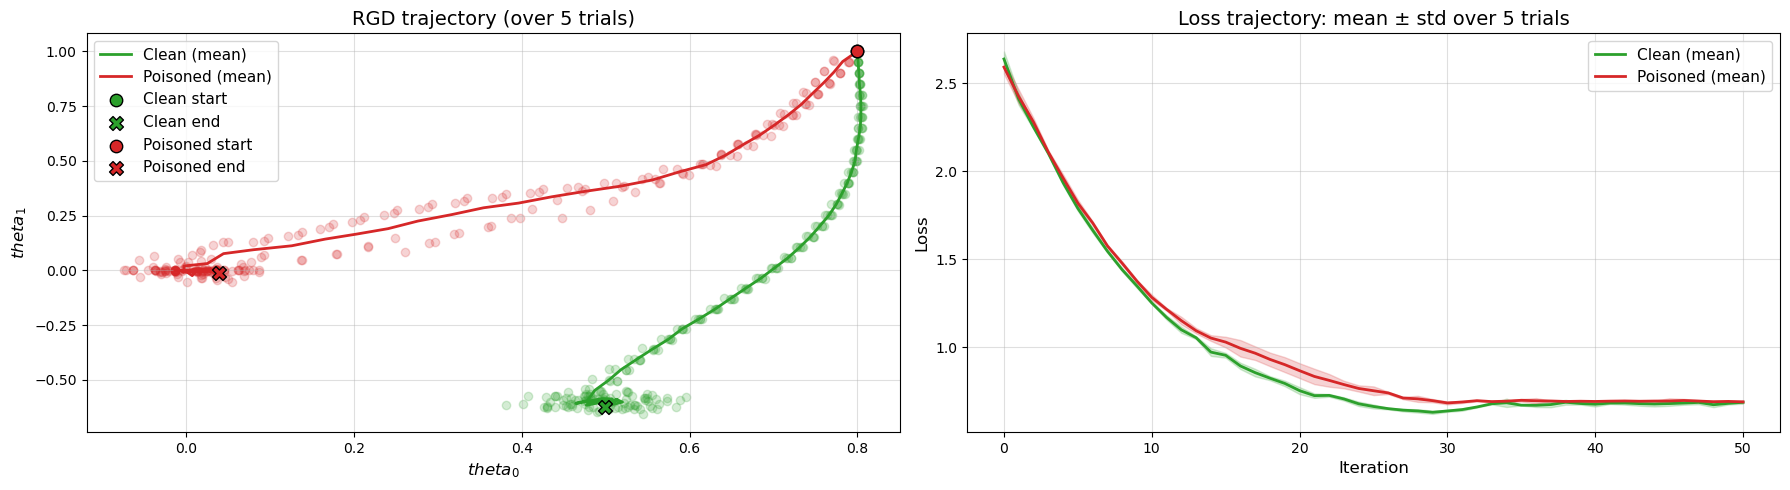

In [ ]:
def binary_classification(
            mu_0: torch.Tensor = torch.tensor([1.0]), 
            mu_1: torch.Tensor = torch.tensor([-1.0]),
            sigma_0: float = 0.25,
            sigma_1: float = 0.25, 
            eps: float = 3,
            Lambda: float = 0.01
    ):

    mu_f = lambda theta: mu_1 - eps * theta[1]

    def D_theta(theta: torch.Tensor, n: int) -> torch.Tensor:
        y = torch.randint(low=0, high=2, size=(n,), dtype=torch.int32)
        x_1 = mu_f(theta).unsqueeze(-1) + torch.sqrt(sigma_1) * torch.randn((n))
        x_0 = mu_0.unsqueeze(-1) + torch.sqrt(sigma_0) * torch.randn((n))
        x = torch.where(y.unsqueeze(0) == 1, x_1, x_0)
        z = torch.vstack((x, y.float()))
        return z

    def loss(z: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
        theta_0 = theta[0]
        theta_1 = theta[1]
        x = z[0, :]
        y = z[1, :]
        h = 1 / (1 + torch.exp(-(theta_0 + theta_1 * x)))
        loss = -y * torch.log(h) - (1 - y) * torch.log(1 - h) + (Lambda / 2) * torch.sum(theta**2)
        return loss.mean() 
    
    return D_theta, loss, mu_f

mu_0: torch.Tensor = torch.tensor([1.0]) 
mu_1: torch.Tensor = torch.tensor([-1.0])
sigma_0: float = torch.tensor(0.25)
sigma_1: float = torch.tensor(0.25)
eps: float = 3
Lambda: float = 0.01

n_trials = 5
eta = 0.05
n = 500
max_iter = 50

D_theta, loss, mu_f = binary_classification(
    mu_0=mu_0, 
    mu_1=mu_1,  
    sigma_0=sigma_0, 
    sigma_1=sigma_1, 
    eps=eps, 
    Lambda=Lambda
)

poison_kwargs = {
    'num_steps': 20,
    'step_size': 1,
    'epsilon': 10,
    'theta_update_estimator': theta_update_estimator,
}

def run_trial(theta_0):

    _, all_theta_clean, all_loss_clean = RGD(
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        poison_function=None
    )
    _, all_theta_poisoned, all_loss_poisoned = RGD(
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        poison_function=white_box_poison_function,
        **poison_kwargs
    )
    
    return all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    theta_0 = torch.tensor([0.8,1.0])
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial(theta_0=theta_0)
    all_theta_clean_list.append(all_theta_clean)
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

# Aggregate across trials and plot mean ± std
def to_float_array(traj):
    return torch.tensor([t.item() if hasattr(t, "item") else float(t) for t in traj], dtype=torch.float32)

clean_stack = torch.stack([torch.stack(traj,-1) for traj in all_theta_clean_list])      # [n_trials, 2, T]
poison_stack = torch.stack([torch.stack(traj,-1) for traj in all_theta_poisoned_list])  # [n_trials, T]

clean_mean = clean_stack.mean(dim=0).numpy()
poison_mean = poison_stack.mean(dim=0).numpy()

# Also process loss trajectories
loss_clean_stack = torch.stack([to_float_array(traj) for traj in all_loss_clean_list])      # [n_trials, T]
loss_poison_stack = torch.stack([to_float_array(traj) for traj in all_loss_poisoned_list])  # [n_trials, T]

loss_clean_mean = loss_clean_stack.mean(dim=0).numpy()
loss_clean_std  = loss_clean_stack.std(dim=0, unbiased=False).numpy()
loss_poison_mean = loss_poison_stack.mean(dim=0).numpy()
loss_poison_std  = loss_poison_stack.std(dim=0, unbiased=False).numpy()

x = np.arange(loss_clean_mean.shape[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,5))

# plot mean trajectories as lines
ax1.plot(clean_mean[0, :], clean_mean[1, :], label='Clean (mean)', color='tab:green', linewidth=2)
ax1.plot(poison_mean[0, :], poison_mean[1, :], label='Poisoned (mean)', color='tab:red', linewidth=2)

for traj in clean_stack:
    ax1.scatter(traj[0, :].numpy(), traj[1, :].numpy(), color='tab:green', alpha=0.2, linewidth=1)
    
for traj in poison_stack:
    ax1.scatter(traj[0, :].numpy(), traj[1, :].numpy(), color='tab:red', alpha=0.2, linewidth=1)

# mark first and last points with two different markers ('o' for start, 'X' for end)
first_idx = 0
last_idx = clean_mean.shape[1] - 1

ax1.scatter(clean_mean[0, first_idx], clean_mean[1, first_idx], marker='o', color='tab:green', s=80, edgecolor='k', zorder=5, label='Clean start')
ax1.scatter(clean_mean[0, last_idx],  clean_mean[1, last_idx],  marker='X', color='tab:green', s=100, edgecolor='k', zorder=6, label='Clean end')

ax1.scatter(poison_mean[0, first_idx], poison_mean[1, first_idx], marker='o', color='tab:red', s=80, edgecolor='k', zorder=5, label='Poisoned start')
ax1.scatter(poison_mean[0, last_idx],  poison_mean[1, last_idx],  marker='X', color='tab:red', s=100, edgecolor='k', zorder=6, label='Poisoned end')

ax1.set_xlabel(r'$theta_0$', fontsize=12)
ax1.set_ylabel(r'$theta_1$', fontsize=12)
ax1.set_title(f'RGD trajectory (over {clean_stack.shape[0]} trials)', fontsize=14)
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.4)

# Plot loss trajectories
ax2.plot(x, loss_clean_mean, label='Clean (mean)', color='tab:green', linewidth=2)
ax2.fill_between(x, loss_clean_mean - loss_clean_std, loss_clean_mean + loss_clean_std, color='tab:green', alpha=0.2)

ax2.plot(x, loss_poison_mean, label='Poisoned (mean)', color='tab:red', linewidth=2)
ax2.fill_between(x, loss_poison_mean - loss_poison_std, loss_poison_mean + loss_poison_std, color='tab:red', alpha=0.2)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title(f'Loss trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax2.legend(loc='best', fontsize=11)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()